In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Hides minor excel reading warnings

print("--- STEP 1: LOADING & CLEANING RAINFALL DATA ---")

# 1. Load the rainfall file and specific sheet
filepath = '/kaggle/input/datasets/shishirpuri/kamala-master-model/Metrology/daily rf.xlsx'
sheet_name = '24h accumulated Precipitation '
rf_df = pd.read_excel(filepath, sheet_name=sheet_name)

# 2. Date column lai datetime ma convert garne ra Time hatayera Date matra rakhne
rf_df['Time (UTC)'] = pd.to_datetime(rf_df['Time (UTC)'], errors='coerce')
rf_df['Time (UTC)'] = rf_df['Time (UTC)'].dt.normalize() 

# 3. Date lai Index banaune ra 2022 dekhi ko data matra line
rf_df.set_index('Time (UTC)', inplace=True)
rf_df = rf_df.loc['2022-01-01':]

# 4. Yadi kunai din 2 choti data aayeko cha bhane teslai mean garera eutai banaune
rf_df = rf_df.groupby(rf_df.index).mean(numeric_only=True)

# 5. Hamro 8 wata required stations matra select garne
rf_cols = [
    'Sindhuli Madhi (mm)', 'Bahun Tilpung (mm)', 'Tulsi (mm)', 'Chisapani Bazar (mm)', 
    'Janakpur Airport (mm)', 'Hardinath (mm)', 'Lahan (mm)', 'Siraha (mm)'
]
rf_data = rf_df[rf_cols]

# 6. Column ko naam clean ra sajilo banaune
rf_data.columns = [
    'Rain_Sindhuli', 'Rain_BahunTilpung', 'Rain_Tulsi', 'Rain_Chisapani', 
    'Rain_Janakpur', 'Rain_Hardinath', 'Rain_Lahan', 'Rain_Siraha'
]

print("✅ Rainfall Data Loaded Successfully!")
print("-" * 50)
print(f"Shape: {rf_data.shape} (Days, Stations)")
print("\nMissing Values (NaNs) per station before any interpolation:")
print(rf_data.isna().sum())
print("-" * 50)
print("\nFirst 3 rows preview:")
print(rf_data.head(3))

--- STEP 1: LOADING & CLEANING RAINFALL DATA ---
✅ Rainfall Data Loaded Successfully!
--------------------------------------------------
Shape: (1627, 8) (Days, Stations)

Missing Values (NaNs) per station before any interpolation:
Rain_Sindhuli         0
Rain_BahunTilpung    32
Rain_Tulsi            0
Rain_Chisapani        0
Rain_Janakpur         0
Rain_Hardinath        1
Rain_Lahan            1
Rain_Siraha           2
dtype: int64
--------------------------------------------------

First 3 rows preview:
            Rain_Sindhuli  Rain_BahunTilpung  Rain_Tulsi  Rain_Chisapani  \
Time (UTC)                                                                 
2022-01-01            0.0                0.0         0.0             0.0   
2022-01-02            0.0                0.0         0.0             0.0   
2022-01-03            0.0                0.0         0.0             0.0   

            Rain_Janakpur  Rain_Hardinath  Rain_Lahan  Rain_Siraha  
Time (UTC)                             

In [2]:
rf_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1627 entries, 2022-01-01 to 2026-06-15
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rain_Sindhuli      1627 non-null   float64
 1   Rain_BahunTilpung  1595 non-null   float64
 2   Rain_Tulsi         1627 non-null   float64
 3   Rain_Chisapani     1627 non-null   float64
 4   Rain_Janakpur      1627 non-null   float64
 5   Rain_Hardinath     1626 non-null   float64
 6   Rain_Lahan         1626 non-null   float64
 7   Rain_Siraha        1625 non-null   float64
dtypes: float64(8)
memory usage: 114.4 KB


In [3]:
print("--- STEP 2: CHOPPING DATA TO MATCH KAMALA TIMELINE ---")

# Define target timeframe with a slight lookback buffer for sequence creation later
START_DATE = '2022-05-20' # Buffer of ~18 days before Kamala data starts (2022-06-08)
END_DATE = '2025-11-05'   # Exact end date of Kamala data

# Chop off the unnecessary past and future data
rf_data_aligned = rf_data.loc[START_DATE:END_DATE]

print(f"✅ Data cropped successfully from {START_DATE} to {END_DATE}")
print("-" * 50)
print(f"New Shape: {rf_data_aligned.shape} (Days, Stations)")
print("\nMissing Values (NaNs) after timeline crop:")
print(rf_data_aligned.isna().sum())
print("-" * 50)

--- STEP 2: CHOPPING DATA TO MATCH KAMALA TIMELINE ---
✅ Data cropped successfully from 2022-05-20 to 2025-11-05
--------------------------------------------------
New Shape: (1266, 8) (Days, Stations)

Missing Values (NaNs) after timeline crop:
Rain_Sindhuli        0
Rain_BahunTilpung    0
Rain_Tulsi           0
Rain_Chisapani       0
Rain_Janakpur        0
Rain_Hardinath       0
Rain_Lahan           0
Rain_Siraha          0
dtype: int64
--------------------------------------------------


--- STEP 3: GRAPHICAL EVALUATION (RAINFALL EDA) ---


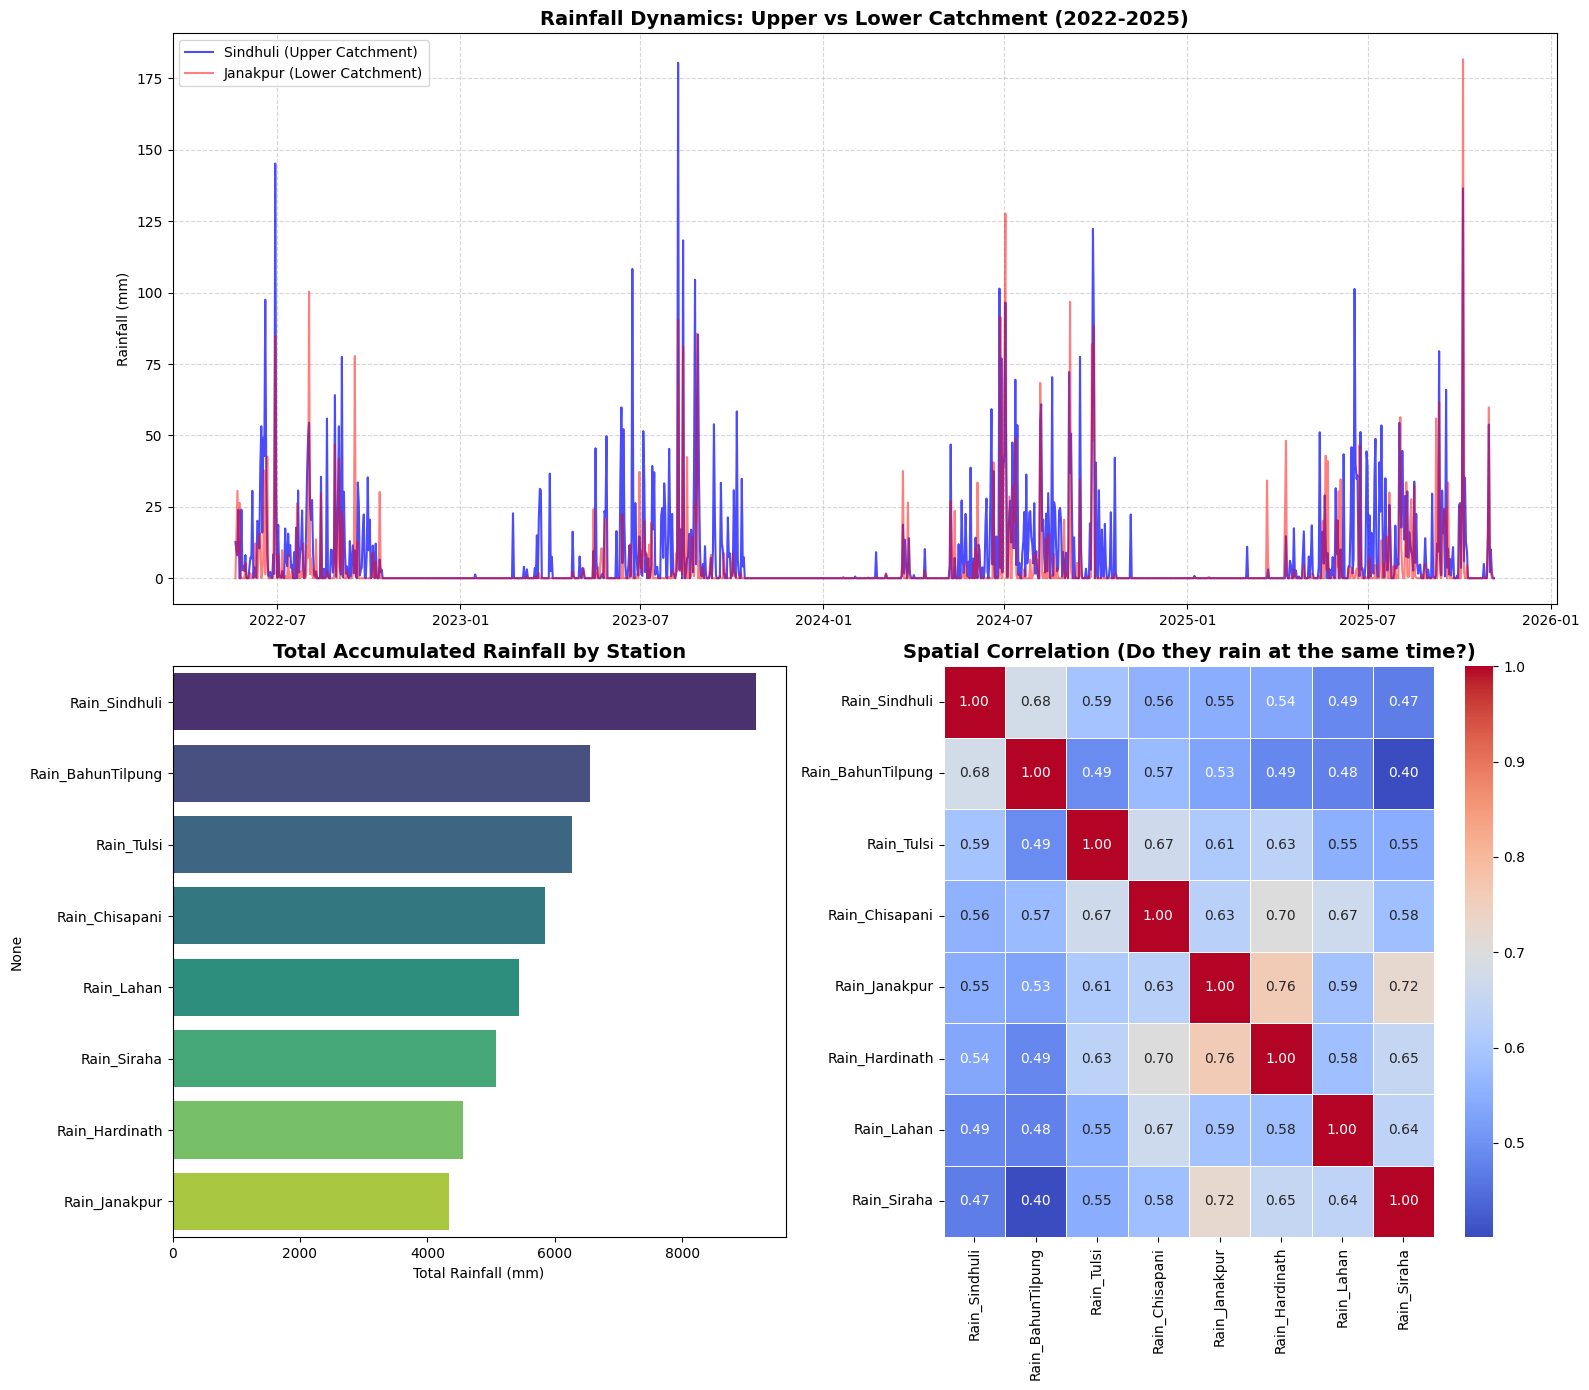

✅ EDA Plots Generated Successfully!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- STEP 3: GRAPHICAL EVALUATION (RAINFALL EDA) ---")

# Setup the figure canvas
fig = plt.figure(figsize=(16, 14))

# -------------------------------------------------------------
# PLOT 1: Time Series Comparison (Upper vs Lower Catchment)
# -------------------------------------------------------------
ax1 = plt.subplot(2, 1, 1) # Top row, spanning full width
# We plot Sindhuli (Mountain/Upper) and Janakpur (Terai/Lower) to see lag
ax1.plot(rf_data_aligned.index, rf_data_aligned['Rain_Sindhuli'], label='Sindhuli (Upper Catchment)', color='blue', alpha=0.7)
ax1.plot(rf_data_aligned.index, rf_data_aligned['Rain_Janakpur'], label='Janakpur (Lower Catchment)', color='red', alpha=0.5)

ax1.set_title('Rainfall Dynamics: Upper vs Lower Catchment (2022-2025)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Rainfall (mm)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# -------------------------------------------------------------
# PLOT 2: Total Accumulated Rainfall (Bar Chart)
# -------------------------------------------------------------
ax2 = plt.subplot(2, 2, 3) # Bottom row, left side
total_rain = rf_data_aligned.sum().sort_values(ascending=False)

sns.barplot(x=total_rain.values, y=total_rain.index, palette='viridis', ax=ax2)
ax2.set_title('Total Accumulated Rainfall by Station', fontsize=14, fontweight='bold')
ax2.set_xlabel('Total Rainfall (mm)')

# -------------------------------------------------------------
# PLOT 3: Spatial Correlation Heatmap
# -------------------------------------------------------------
ax3 = plt.subplot(2, 2, 4) # Bottom row, right side
corr_matrix = rf_data_aligned.corr()

# Heatmap shows how closely stations follow the same rain patterns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax3)
ax3.set_title('Spatial Correlation (Do they rain at the same time?)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ EDA Plots Generated Successfully!")

In [8]:
import pandas as pd

print("--- STEP 4: PROCESSING TEMP, HUMIDITY & CREATING MASTER WEATHER DATA ---")

# Define our strict timeline again
START_DATE = '2022-05-20'
END_DATE = '2025-11-05'

# Helper function to load, clean, and chop data
def process_weather_sheet(filepath, sheet_name, cols_to_keep, col_prefix):
    df = pd.read_excel(filepath, sheet_name=sheet_name)
    df['Time (UTC)'] = pd.to_datetime(df['Time (UTC)'], errors='coerce').dt.normalize()
    df.set_index('Time (UTC)', inplace=True)
    df = df.groupby(df.index).mean(numeric_only=True)
    
    # Keep only required stations and chop to our timeline
    df = df[cols_to_keep].loc[START_DATE:END_DATE]
    
    # Rename columns (e.g., Sindhuli Madhi (°C) -> MaxT_Sindhuli)
    df.columns = [f"{col_prefix}_{col.split(' (')[0].replace(' ', '')}" for col in cols_to_keep]
    return df

# The 5 stations we are using for Thermodynamics
thermo_stations = ['Sindhuli Madhi (°C)', 'Janakpur Airport (°C)', 'Hardinath (°C)', 'Lahan (°C)', 'Siraha (°C)']
hum_stations = ['Sindhuli Madhi (%)(Avg)', 'Janakpur Airport (%)(Avg)', 'Hardinath (%)(Avg)', 'Lahan (%)(Avg)', 'Siraha (%)(Avg)']

# 1. Process Max Temp, Min Temp, and Humidity
print("Processing Maximum Temperature...")
tmax_aligned = process_weather_sheet('/kaggle/input/datasets/shishirpuri/kamala-master-model/Metrology/daily temp.xlsx', 'Manual Daily Maximum Air Tempe', thermo_stations, 'MaxT')

print("Processing Minimum Temperature...")
tmin_aligned = process_weather_sheet('/kaggle/input/datasets/shishirpuri/kamala-master-model/Metrology/daily temp.xlsx', 'Manual Daily Minimum Air Tempe', thermo_stations, 'MinT')

print("Processing Relative Humidity...")
rh_aligned = process_weather_sheet('/kaggle/input/datasets/shishirpuri/kamala-master-model/Metrology/daily rh everage.xlsx', 'Manual Relative Humidity', hum_stations, 'Hum')

# 2. Merge everything with our previously created rf_data_aligned
# Using pd.concat ensures they are perfectly matched by the Date index
print("Merging all meteorological features...")
meteorology_master = pd.concat([rf_data_aligned, tmax_aligned, tmin_aligned, rh_aligned], axis=1)

# 3. Final interpolation for any missing values strictly within this chopped timeline
initial_nans = meteorology_master.isna().sum().sum()
meteorology_master.interpolate(method='linear', limit=7, inplace=True)
final_nans = meteorology_master.isna().sum().sum()

# 4. Save the raw, unscaled master data for the next phase
output_filename = 'meteorology_master_unscaled.csv'
meteorology_master.to_csv(output_filename)

print(f"\n✅ SUCCESS! Master Meteorological Data saved as '{output_filename}'")
print("-" * 50)
print(f"Final Shape       : {meteorology_master.shape} (Days, Features)")
print(f"Total Features    : {len(meteorology_master.columns)} (8 Rain + 5 MaxT + 5 MinT + 5 Hum)")
print(f"Interpolated NaNs : {initial_nans - final_nans}")
print(f"Remaining NaNs    : {final_nans} (Should be 0)")
print("-" * 50)
print("Preview of Final Master Data:")
print(meteorology_master.head(2))

--- STEP 4: PROCESSING TEMP, HUMIDITY & CREATING MASTER WEATHER DATA ---
Processing Maximum Temperature...
Processing Minimum Temperature...
Processing Relative Humidity...
Merging all meteorological features...

✅ SUCCESS! Master Meteorological Data saved as 'meteorology_master_unscaled.csv'
--------------------------------------------------
Final Shape       : (1266, 23) (Days, Features)
Total Features    : 23 (8 Rain + 5 MaxT + 5 MinT + 5 Hum)
Interpolated NaNs : 8
Remaining NaNs    : 0 (Should be 0)
--------------------------------------------------
Preview of Final Master Data:
            Rain_Sindhuli  Rain_BahunTilpung  Rain_Tulsi  Rain_Chisapani  \
Time (UTC)                                                                 
2022-05-20           12.7               31.0         6.0             5.5   
2022-05-21            9.7                7.5         3.1             3.0   

            Rain_Janakpur  Rain_Hardinath  Rain_Lahan  Rain_Siraha  \
Time (UTC)                         

--- STEP 5: DEEP EDA & ANOMALY DETECTION ---


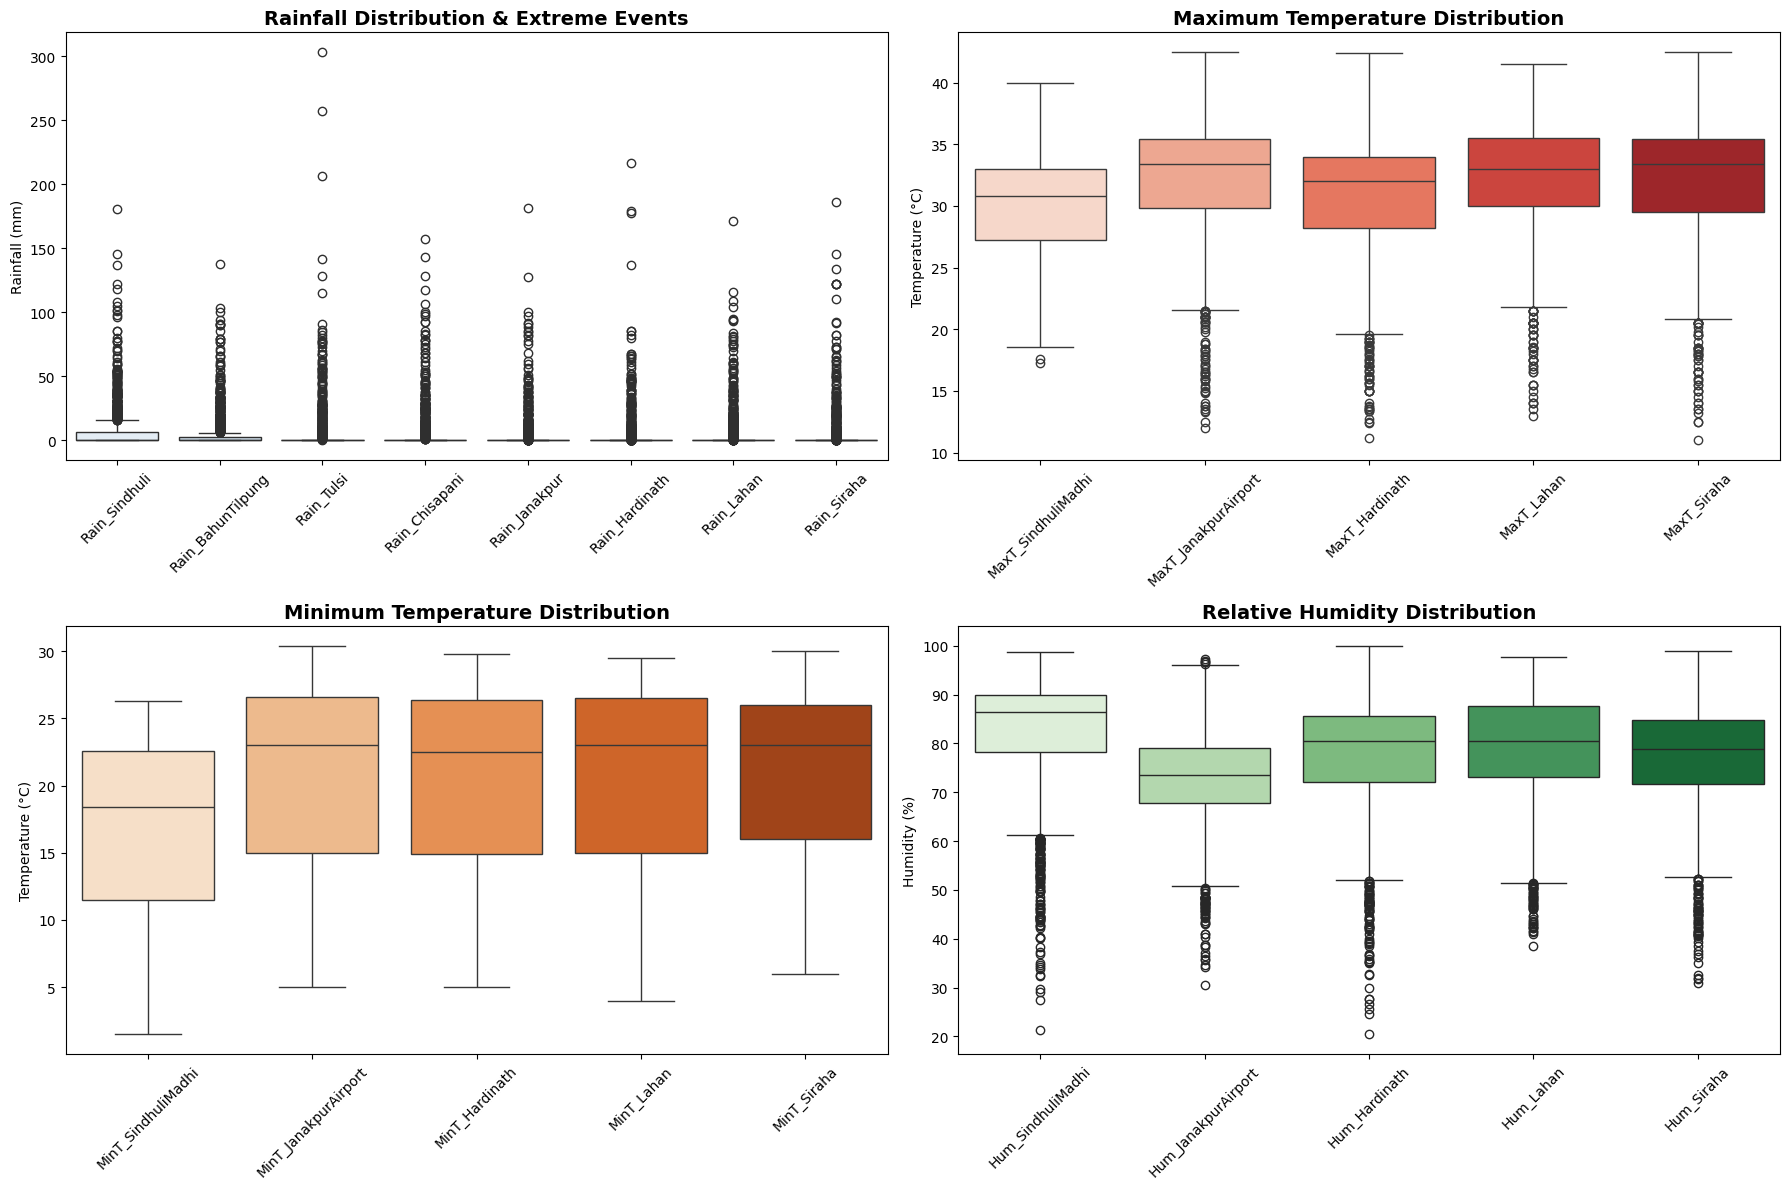


🔍 LOGICAL ANOMALY CHECK RESULTS:
--------------------------------------------------
Rainfall values < 0 mm  : 0 (Should be 0)
Max Temp > 50°C         : 0 (Should be 0 in Nepal)
Min Temp < -10°C        : 0 (Should be 0 in Terai/Lower Hills)
Humidity > 100%         : 0 (Should be 0)
Humidity < 0%           : 0 (Should be 0)
--------------------------------------------------


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- STEP 5: DEEP EDA & ANOMALY DETECTION ---")

# Setup the plotting area (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Rainfall Boxplot (Looking for natural extreme peaks)
sns.boxplot(data=meteorology_master.iloc[:, 0:8], ax=axes[0, 0], palette="Blues")
axes[0, 0].set_title("Rainfall Distribution & Extreme Events", fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel("Rainfall (mm)")
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Max Temperature Boxplot (Looking for sensor errors > 50C or < 0C)
sns.boxplot(data=meteorology_master.iloc[:, 8:13], ax=axes[0, 1], palette="Reds")
axes[0, 1].set_title("Maximum Temperature Distribution", fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel("Temperature (°C)")
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Min Temperature Boxplot
sns.boxplot(data=meteorology_master.iloc[:, 13:18], ax=axes[1, 0], palette="Oranges")
axes[1, 0].set_title("Minimum Temperature Distribution", fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel("Temperature (°C)")
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Humidity Boxplot (Looking for values > 100% or < 0%)
sns.boxplot(data=meteorology_master.iloc[:, 18:23], ax=axes[1, 1], palette="Greens")
axes[1, 1].set_title("Relative Humidity Distribution", fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel("Humidity (%)")
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# LOGICAL ANOMALY CHECK (Mathematical Rule-Based Check)
# ---------------------------------------------------------
print("\n🔍 LOGICAL ANOMALY CHECK RESULTS:")
print("-" * 50)

# 1. Rainfall Checks
print(f"Rainfall values < 0 mm  : {(meteorology_master.iloc[:, 0:8] < 0).sum().sum()} (Should be 0)")

# 2. Temperature Checks
max_t_extreme = (meteorology_master.iloc[:, 8:13] > 50).sum().sum()
min_t_extreme = (meteorology_master.iloc[:, 13:18] < -10).sum().sum()
print(f"Max Temp > 50°C         : {max_t_extreme} (Should be 0 in Nepal)")
print(f"Min Temp < -10°C        : {min_t_extreme} (Should be 0 in Terai/Lower Hills)")

# 3. Humidity Checks
hum_high = (meteorology_master.iloc[:, 18:23] > 100).sum().sum()
hum_low = (meteorology_master.iloc[:, 18:23] < 0).sum().sum()
print(f"Humidity > 100%         : {hum_high} (Should be 0)")
print(f"Humidity < 0%           : {hum_low} (Should be 0)")
print("-" * 50)